In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, datasets

from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

import math

In [ ]:
# For GPU computation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
# Loading the Oxford Flowers-102 dataset

img_size = 64

data_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),                          # All imgs have different img_size, so we make all img of same size
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5]*3, std = [0.5]*3)   # Scales image pixel values from [0.0, 1.0] to [-1.0, 1.0]
])

train_data = datasets.Flowers102(root = './data', split = 'train', download = True, transform = data_transform)    # 1020 imgs
test_data = datasets.Flowers102(root = './data', split = 'test', download = True, transform = data_transform)      # 6149 imgs
val_data = datasets.Flowers102(root = './data', split = 'val', download = True, transform = data_transform)        # 1020 imgs

# Since training data is very small(1020 imgs), we add training, testing, validation together to make training data
full_dataset = torch.utils.data.ConcatDataset([train_data, test_data, val_data])

100%|██████████| 345M/345M [00:14<00:00, 24.5MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.56MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 10.3MB/s]


In [ ]:
# Lable mapping of the dataset

label_val = {0: "pink primrose", 1: "hard-leaved pocket orchid", 2: "canterbury bells", 3: "sweet pea", 4: "english marigold", 5: "tiger lily", 6: "moon orchid", 7: "bird of paradise", 8: "monkshood", 9: "globe thistle", 10: "snapdragon", 11: "colt's foot", 12: "king protea", 13: "spear thistle", 14: "yellow iris", 15: "globe-flower", 16: "purple coneflower", 17: "peruvian lily", 18: "balloon flower", 19: "giant white arum lily", 20: "fire lily", 21: "pincushion flower", 22: "fritillary", 23: "red ginger", 24: "grape hyacinth", 25: "corn poppy", 26: "prince of wales feathers", 27: "stemless gentian", 28: "artichoke", 29: "sweet william", 30: "carnation", 31: "garden phlox", 32: "love in the mist", 33: "mexican aster", 34: "alpine sea holly", 35: "ruby-lipped cattleya", 36: "cape flower", 37: "great masterwort", 38: "siam tulip", 39: "lenten rose", 40: "barbeton daisy", 41: "daffodil", 42: "sword lily", 43: "poinsettia", 44: "bolero deep blue", 45: "wallflower", 46: "marigold", 47: "buttercup", 48: "oxeye daisy", 49: "common dandelion", 50: "petunia", 51: "wild pansy", 52: "primula", 53: "sunflower", 54: "pelargonium", 55: "bishop of llandaff", 56: "gaura", 57: "geranium", 58: "orange dahlia", 59: "pink-yellow dahlia", 60: "cautleya spicata", 61: "japanese anemone", 62: "black-eyed susan", 63: "silverbush", 64: "californian poppy", 65: "osteospermum", 66: "spring crocus", 67: "bearded iris", 68: "windflower", 69: "tree poppy", 70: "gazania", 71: "azalea", 72: "water lily", 73: "rose", 74: "thorn apple", 75: "morning glory", 76: "passion flower", 77: "lotus", 78: "toad lily", 79: "anthurium", 80: "frangipani", 81: "clematis", 82: "hibiscus", 83: "columbine", 84: "desert-rose", 85: "tree mallow", 86: "magnolia", 87: "cyclamen", 88: "watercress", 89: "canna lily", 90: "hippeastrum", 91: "bee balm", 92: "ball moss", 93: "foxglove", 94: "bougainvillea", 95: "camellia", 96: "mallow", 97: "mexican petunia", 98: "bromelia", 99: "blanket flower", 100: "trumpet creeper", 101: "blackberry lily"}

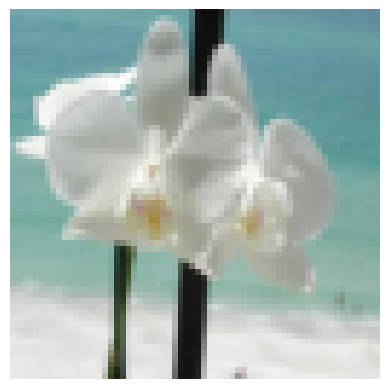

torch.Size([3, 64, 64]) 
Name of the flower:  moon orchid
Total images in dataset:  8189


In [ ]:
# Visualizing the data

sample_image, label = full_dataset[64]

# Denormalize the image for correct display
image_to_display = (sample_image * 0.5) + 0.5       # Reverse the normalization: (tensor * std) + mean, because matplotlib.imshow expects
                                                    # pixel values to be in the [0.0, 1.0] range for floating-point data

plt.imshow(image_to_display.permute(1, 2, 0))       # (C, H, W) --> (H, W, C), ex: (3, 128, 128) --> (128, 128, 3)
plt.axis('off')
plt.show()

print(sample_image.size(), '\nName of the flower: ', label_val[label])
print('Total images in dataset: ', len(full_dataset))

In [ ]:
# DataLoader

Batch_Size = 32

train_loader = DataLoader(full_dataset, batch_size = Batch_Size, shuffle = True)

In [ ]:
# VAE

class VAE(nn.Module):
  def __init__(self):
    super().__init__()

    # Encode
    self.en_c1 = nn.Conv2d(3, 6, 3, stride = 2, padding = 1)         # o/p: [6, 32, 32] ([3, 64, 64] --> [6, 32, 32])
    self.en_gn1 = nn.GroupNorm(2, 6)
    self.en_c2 = nn.Conv2d(6, 12, 3, stride = 2, padding = 1)        # o/p: [12, 16, 16]
    self.en_gn2 = nn.GroupNorm(4, 12)
    self.en_mu = nn.Conv2d(12, 24, 3, stride = 2, padding = 1)       # o/p: [24, 8, 8]
    self.en_logvar = nn.Conv2d(12, 24, 3, stride = 2, padding = 1)   # o/p: [24, 8, 8]

    # Decode
    self.de_c1 = nn.ConvTranspose2d(24, 12, 4, stride = 2, padding = 1)  # o/p: [12, 16, 16] ([24, 8, 8] --> [12, 16, 16])
    self.de_gn1 = nn.GroupNorm(4, 12)
    self.de_c2 = nn.ConvTranspose2d(12, 6, 4, stride = 2, padding = 1)   # o/p: [6, 32, 32]
    self.de_gn2 = nn.GroupNorm(2, 6)
    self.de_c3 = nn.ConvTranspose2d(6, 3, 4, stride = 2, padding = 1)    # o/p: [3, 64, 64]

    # Activation function
    self.silu = nn.SiLU()
    self.tanh = nn.Tanh()

  # Encoder
  def encoder(self, x):
    x = self.silu(self.en_gn1(self.en_c1(x)))
    x = self.silu(self.en_gn2(self.en_c2(x)))
    mu = self.en_mu(x)
    logvar = self.en_logvar(x)
    return mu, logvar

  # Reparameterization
  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar)                               # Standard deviation is sigma, while sigma square is the variance
    eps = torch.randn_like(std)
    z = mu + eps*std
    return z

  # Decoder
  def decoder(self, z):
    z = self.silu(self.de_gn1(self.de_c1(z)))
    z = self.silu(self.de_gn2(self.de_c2(z)))
    out = self.tanh(self.de_c3(z))
    return out

  # Forward
  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = self.reparameterize(mu, logvar)
    x_recon = self.decoder(z)
    return x_recon, mu, logvar

In [ ]:
# Defining Loss function of VAE

def VAE_loss_fn(x, x_recon, mu, logvar):

  reconstruction_loss = nn.functional.mse_loss(x_recon, x, reduction = 'sum')

  variance = torch.exp(logvar)
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - variance)

  total_loss = reconstruction_loss + kl_loss

  return total_loss

In [ ]:
# Initializing the model, and defining the optimizer

VAE_model = VAE()
VAE_model = VAE_model.to(device)

optimizer = optim.Adam(VAE_model.parameters(), lr = 1e-3)

In [ ]:
# Training

Epoch = 30

for epoch in range(Epoch):
  total_epoch_loss = 0                           # Reseting total_epoch_loss for each epoch

  for x, _ in train_loader:

    x = x.to(device)

    optimizer.zero_grad()
    x_recon, mu, logvar = VAE_model(x)

    loss = VAE_loss_fn(x, x_recon, mu, logvar)
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()            # Accumulating batch loss

  # Calculating average epoch loss
  avg_epoch_loss = total_epoch_loss / len(train_loader)

  print(f'Epoch [{epoch+1}/{Epoch}]: Loss: {avg_epoch_loss:.4f}')

Epoch [1/30]: Loss: 65761.2753
Epoch [2/30]: Loss: 37404.4630
Epoch [3/30]: Loss: 33682.6238
Epoch [4/30]: Loss: 30945.5089
Epoch [5/30]: Loss: 29204.6684
Epoch [6/30]: Loss: 28365.7132
Epoch [7/30]: Loss: 27727.9372
Epoch [8/30]: Loss: 27274.3044
Epoch [9/30]: Loss: 27033.9868
Epoch [10/30]: Loss: 26827.1740
Epoch [11/30]: Loss: 26652.0269
Epoch [12/30]: Loss: 26542.0739
Epoch [13/30]: Loss: 26418.0386
Epoch [14/30]: Loss: 26342.1205
Epoch [15/30]: Loss: 26259.7981
Epoch [16/30]: Loss: 26196.2687
Epoch [17/30]: Loss: 26118.2760
Epoch [18/30]: Loss: 26083.8149
Epoch [19/30]: Loss: 26029.2340
Epoch [20/30]: Loss: 25993.3348
Epoch [21/30]: Loss: 25942.9960
Epoch [22/30]: Loss: 25897.8679
Epoch [23/30]: Loss: 25868.8293
Epoch [24/30]: Loss: 25836.2937
Epoch [25/30]: Loss: 25818.8974
Epoch [26/30]: Loss: 25760.0930
Epoch [27/30]: Loss: 25775.6288
Epoch [28/30]: Loss: 25724.9964
Epoch [29/30]: Loss: 25728.9722
Epoch [30/30]: Loss: 25691.4089


In [ ]:
# Collecting all the mean(mu) values for an image in the dataset

VAE_model.eval()

all_mu = []
with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        mu, logvar = VAE_model.encoder(x)   # only need mu, as discussed
        all_mu.append(mu.cpu())

all_latents = torch.cat(all_mu, dim=0)      # shape: (N, 24, 8, 8), N = total dataset size

In [ ]:
# Creating Latent_loader

latent_dataset = TensorDataset(all_latents)
latent_loader = DataLoader(latent_dataset, batch_size=64, shuffle=True)

# sanity check
z_batch, = next(iter(latent_loader))
print(z_batch.shape)                                          # should print torch.Size([64, 24, 8, 8])

torch.Size([64, 24, 8, 8])


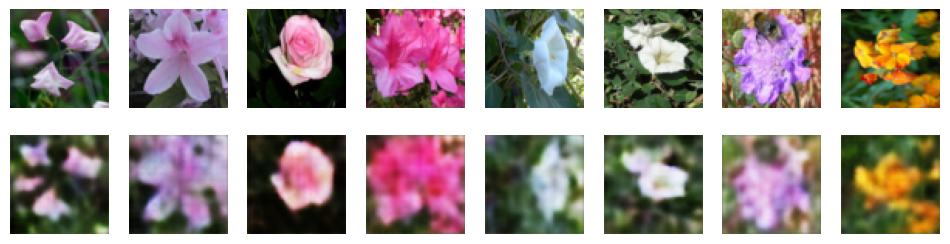

In [ ]:
# Generating samples from trained VAE model (on the trained data)

VAE_model.eval()

with torch.no_grad():

  x, _ = next(iter(train_loader))
  x = x.to(device)

  x_recon, _, _ = VAE_model.forward(x)

  n = 8                                           # n --> Number of images to plot
  plt.figure(figsize = (12, 3))

  for i in range(n):
    # Denormalize original image for display
    original_img_display = (x[i] * 0.5) + 0.5

    # Original image
    plt.subplot(2, n, i+1)
    plt.imshow(original_img_display.cpu().permute(1, 2, 0))
    plt.axis('off')

    # Denormalize reconstructed image for display
    reconstructed_img_display = (x_recon[i] * 0.5) + 0.5

    # Reconstructed image
    plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed_img_display.cpu().permute(1, 2, 0))
    plt.axis('off')

  plt.show()

# DDIM in Latent space starts here

In [ ]:
# Noise schedule

T = 1000
beta = torch.linspace(1e-4, 0.02, T, device = device)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, dim = 0)

In [ ]:
# Forward diffusion

def forward_diffusion(z_0, T):

  noise = torch.randn_like(z_0)

  alpha_bar_T = alpha_bar[T].view(-1, 1, 1, 1)   # (batch_size, 1, 1, 1): to match the (B, C, H, W) of z_0 and noise

  z_t = torch.sqrt(alpha_bar_T) * z_0 + torch.sqrt(1 - alpha_bar_T) * noise

  return z_t, noise

In [ ]:
# Time Embedding

class Time_embedding(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()

    self.emb_dim = emb_dim

    # MLP
    self.mlp = nn.Sequential(
        nn.Linear(emb_dim, emb_dim),
        nn.SiLU(),
        nn.Linear(emb_dim, emb_dim)
    )

  def forward(self, t):

    emb_dim = self.emb_dim
    half = emb_dim // 2

    freq = torch.exp(-math.log(10000) * 2 * torch.arange(half, device = device) / half)    # The denominator coming to numerator: exp(-log(10000)*2i/d)

    t = t.unsqueeze(-1).float()        # (B,) -> (B, 1)
    freq = freq.unsqueeze(0)           # (half,) -> (1, half)
    args = t * freq                    # (B,1) * (1,half) -> (B, half)

    time_vec = torch.cat([torch.sin(args), torch.cos(args)], dim = -1)

    time_vec = self.mlp(time_vec)

    return time_vec

In [ ]:
# Resblock

class Resblock(nn.Module):
  def __init__(self, ch_in, ch_out, emb_dim):
    super().__init__()

    # Block 1
    self.gn1 = nn.GroupNorm(max(1, ch_in//4), ch_in)
    self.silu1 = nn.SiLU()
    self.conv1 = nn.Conv2d(ch_in, ch_out, 3, padding = 1)

    # Making time_vec's number of channel equal to number of channel in the o/p of conv1, so that we can do element-wise addintion across channel
    self.time_proj = nn.Linear(emb_dim, ch_out)

    # Block 2
    self.gn2 = nn.GroupNorm(max(1, ch_out//4), ch_out)
    self.silu2 = nn.SiLU()
    self.conv2 = nn.Conv2d(ch_out, ch_out, 3, padding = 1)

  def forward(self, x, time_vec):
    x = self.gn1(x)
    x = self.silu1(x)
    x = self.conv1(x)

    # Changing the shape of time_vec
    time_vec = self.time_proj(time_vec)                     # (B, emb_dim) -> (B, C)
    time_vec = time_vec.view(time_vec.shape[0], -1, 1, 1)   # (B, C) -> (B, C, 1, 1)

    # Adding Time vector across the channel
    x = x + time_vec

    x = self.gn2(x)
    x = self.silu2(x)
    x = self.conv2(x)

    return x

In [ ]:
# Self-attention

class self_attention(nn.Module):
  def __init__(self, ch_in):
    super().__init__()

    self.gn = nn.GroupNorm(max(1, ch_in//4), ch_in)
    self.q = nn.Conv2d(ch_in, ch_in, 1)
    self.k = nn.Conv2d(ch_in, ch_in, 1)
    self.v = nn.Conv2d(ch_in, ch_in, 1)

    self.proj = nn.Conv2d(ch_in, ch_in, 1)

  def forward(self, x):

    B, C, H, W = x.shape

    x = self.gn(x)

    q = self.q(x).reshape(B, C, H*W)          # [B, C, H, W] --> [B, C, H*W], we do H*W cause every pixel is treated as token
    k = self.k(x).reshape(B, C, H*W)          # [B, C, H, W] --> [B, C, H*W]
    v = self.v(x).reshape(B, C, H*W)          # [B, C, H, W] --> [B, C, H*W]

    attn = torch.softmax((q.transpose(1,2)@k) / math.sqrt(C), dim = -1)   # [B, H*W, C] @ [B, C, H*W] = [B, H*W, H*W]
    attn = attn @ v.transpose(1,2)                                        # [B, H*W, H*W] @ [B, H*W, C] = [B, H*W, C]
    attn = attn.transpose(1,2)                                            # [B, H*W, C] --> [B, C, H*W]

    attn = attn.reshape(B, C, H, W)                                       # Reshaping from [B, C, H*W] --> [B, C, H, W]

    attn = self.proj(attn)

    return x + attn

In [ ]:
class Unet(nn.Module):
  def __init__(self):
    super().__init__()

    # Encoder level 1
    self.en_res1 = Resblock(24, 24, 128)
    self.en_res2 = Resblock(24, 48, 128)
    self.en_down1 = nn.Conv2d(48, 48, 3, stride = 2, padding = 1)

    # Bottleneck
    self.b_res1 = Resblock(48, 48, 128)
    self.b_attn = self_attention(48)
    self.b_res2 = Resblock(48, 48, 128)

    # Decoder level 1
    self.de_up1 = nn.ConvTranspose2d(48, 24, 3, stride = 2, padding = 1, output_padding = 1)
    self.de_res1 = Resblock(72, 24, 128)
    self.de_res2 = Resblock(24, 24, 128)

    # Final 3x3 conv layer
    self.out = nn.Conv2d(24, 24, 3, padding = 1)

  def forward(self, z, time_vec):            # z: [B, 24, 8, 8]

    # Encoder
    skip = []

    z = self.en_res1(z, time_vec)
    z = self.en_res2(z, time_vec)
    skip.append(z)
    z = self.en_down1(z)

    # Bottleneck
    z = self.b_res1(z, time_vec)
    z = self.b_attn(z)
    z = self.b_res2(z, time_vec)

    # Decoder
    z = self.de_up1(z)
    z = torch.cat([z, skip[0]], dim = 1)
    z = self.de_res1(z, time_vec)
    z = self.de_res2(z, time_vec)

    # Final 3x3 conv layer
    z = self.out(z)

    return z

In [ ]:
# Initializing the U-Net model, and defining the optimizer

unet = Unet()
unet = unet.to(device)

# Creating time object once, and using this same object every time we need it to make the timestep vector. Because there is mlp in it,
# which gets trained during the training epochs. But if we make the object again  we get a brand new object with freshly randomized
# weights it will not use the trained weights of the mlp that were learned during training. So make 1 object and use it every other
# time you need it.
time_emb_object = Time_embedding(128).to(device)

optimizer = optim.Adam(list(unet.parameters()) + list(time_emb_object.parameters()), lr = 1e-3)

In [ ]:
# Training of DDIM

Epoch = 10

for epoch in range(Epoch):
  total_epoch_loss = 0

  for (z,) in latent_loader:

    z = z.to(device)

    t = torch.randint(0, T, (z.shape[0],), device=device)     # Gives a 1D tensor of Shape: [Batch_Size], where the values are Random
                                           # integers sampled uniformly from the range [0, T-1]. For eg: If batch size (z.shape[0]) is 4,
                                           # then t = tensor([12, 850, 431,  0], device='cuda')

    # Forward diffusion
    z_t, noise = forward_diffusion(z, t)

    # Time embedding
    time_vec = time_emb_object(t)

    # Using U-Net to predict noise
    noise_pred = unet.forward(z_t, time_vec)

    # Loss function
    loss = nn.functional.mse_loss(noise_pred, noise)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_epoch_loss = total_epoch_loss / len(latent_loader)

  print(f'Epoch [{epoch + 1}/{Epoch}]: Loss: {avg_epoch_loss:.5f}')

Epoch [1/10]: Loss: 0.91954
Epoch [2/10]: Loss: 0.80040
Epoch [3/10]: Loss: 0.73486
Epoch [4/10]: Loss: 0.68328
Epoch [5/10]: Loss: 0.64416
Epoch [6/10]: Loss: 0.61839
Epoch [7/10]: Loss: 0.59965
Epoch [8/10]: Loss: 0.58859
Epoch [9/10]: Loss: 0.57464
Epoch [10/10]: Loss: 0.55979


In [ ]:
# Reverse diffusion using DDIM

@torch.no_grad()

def rev_diff(unet_model, stride):

  unet_model.eval()

  z_s = torch.randn((32, 24, 8, 8), device = device)  # Pure noise

  eta = 0                                             # Deterministic sampling

  # Timestep subsequence
  timestep = torch.arange(0, T, stride, device = device)
  timestep = torch.flip(timestep, dims = [0])

  for i in range(len(timestep)):

    t_scalar = timestep[i].item()
    t_batch = torch.full((z_s.shape[0],), t_scalar, device=device, dtype=torch.long)  # [32] (a 1D vector matching batch size).
                         # For eg: if timestep[i] = 750, then t_batch = tensor([750, 750, 750, ..., 750], device='cuda', dtype=torch.long)
    time_vec = time_emb_object(t_batch)

    noise_pred = unet_model(z_s, time_vec)

    # Value of alpha_bar at current step (t) and next, smaller step (s)
    alpha_bar_t = alpha_bar[timestep[i]]
    if i + 1 < len(timestep):
      alpha_bar_s = alpha_bar[timestep[i+1]]
    else:
      alpha_bar_s = torch.tensor(1.0, device=device)     # final step: target "zero noise"


    z0_pred = (z_s - torch.sqrt(1 - alpha_bar_t) * noise_pred) / torch.sqrt(alpha_bar_t)

    sigma_t = eta * torch.sqrt((1 - alpha_bar_s) / (1 - alpha_bar_t)) * torch.sqrt(1 - (alpha_bar_t / alpha_bar_s))

    # Random noise term (only contributes if eta > 0)
    z_dash = torch.randn_like(z_s) if eta > 0 else 0

    z_s = torch.sqrt(alpha_bar_s) * z0_pred + torch.sqrt(1 - alpha_bar_s - sigma_t**2) * noise_pred + sigma_t * z_dash

  return z_s

In [ ]:
# VAE Decoder to get x_pred from z

@torch.no_grad()

def decode_latents(VAE_model, z):

    VAE_model.eval()

    x_pred = VAE_model.decoder(z)     # (B, 24, 8, 8) -> (B, 3, 64, 64), values in [-1, 1] due to Tanh

    return x_pred

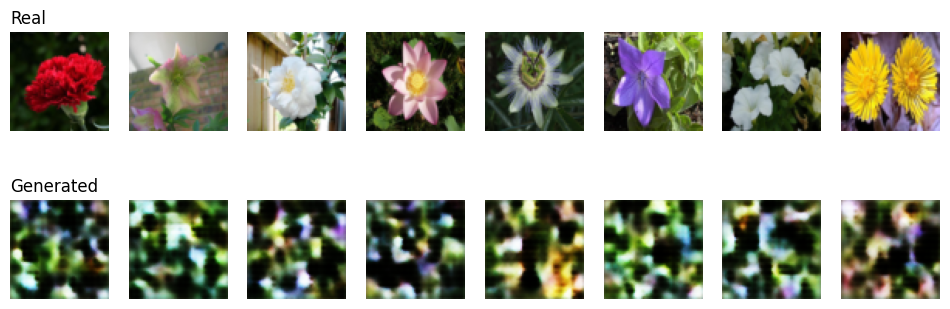

In [ ]:
n_samples = 8

# Real images (for comparison)
x_real, _ = next(iter(train_loader))
x_real = x_real.to(device)

# Generated images
z_generated = rev_diff(unet, stride=20)
x_generated = decode_latents(VAE_model, z_generated)

plt.figure(figsize=(12, 4))
for i in range(n_samples):
    # Row 1: real
    plt.subplot(2, n_samples, i+1)
    real_img = (x_real[i] * 0.5 + 0.5).clamp(0, 1)
    plt.imshow(real_img.cpu().permute(1, 2, 0))
    plt.axis('off')
    if i == 0: plt.title('Real', loc='left')

    # Row 2: generated
    plt.subplot(2, n_samples, i+1+n_samples)
    gen_img = (x_generated[i] * 0.5 + 0.5).clamp(0, 1)
    plt.imshow(gen_img.cpu().permute(1, 2, 0))
    plt.axis('off')
    if i == 0: plt.title('Generated', loc='left')

plt.show()